
## Opening
In the last notebook(mould-risk-analysis-v2), I promised to follow up with a version 3 featuring the newly installed dMEV-styled fan.
The goal of this notebook is to quantify and validate the exact impact of the new fan-specifically, how much quicker the room recovers from the risk zone(dew point spread <= 3)

To evaluate this, I compared the following three periods: 
1. The 2 weeks leading up to 11/05/2026 (Baseline)
2. The first 2 weeks immediately after 11/05/2026 (Fan + dehumidifier + Window open after a shower)
3. The 2-week period starting from 09/06/2026 (Fan + Window open at the beginning of a shower)

To get an initial feel for the data, I first plotted a scatter plot, which revealed a distict, recurring arc pattern.



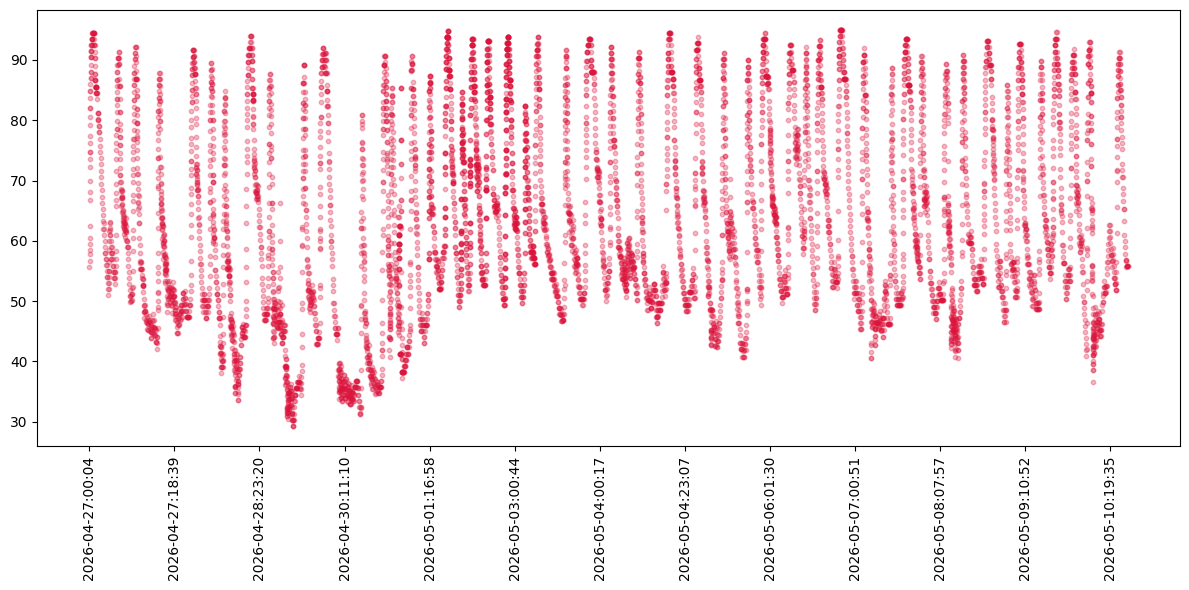

In [232]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from typing import NamedTuple

from matplotlib.colors import Normalize
import matplotlib.cm as cm


class BoxWhiskerResult(NamedTuple):
    clean_data: pd.DataFrame
    q1: float
    median: float
    q3: float
    mean: float
    upper_whisker: float
    actual_upper_whisker: float
    outliers_df: pd.DataFrame  
    outlier_val: float
    summary: pd.Series
    desc_base: pd.Series

# difficult to decide noise level, and decide on deflecting noise process
NOISE_THRESHOLD = 0.5

pd.set_option('display.max_rows', None)
df = pd.read_csv('./data/humid_temp_readings_v3.csv')
df = df[df['label'] == 'bathroom/bathtub_shelf_humid_temp_sensor'].copy()
df['ts'] = pd.to_datetime(df['received_at'], utc=True).dt.tz_convert('Europe/London')


df['date'] = df['ts'].dt.strftime('%Y-%m-%d:%H:%M')
# dbs usually save data in heap file randomly so, default, innodb mySQL uses, uses covering indexing(indexing file has the data -> indexing table is actually just tables, they all have indexed col)

w1_start = pd.to_datetime('2026-04-27').tz_localize('Europe/London')
w1_end = pd.to_datetime('2026-05-11').tz_localize('Europe/London')

w2_start = pd.to_datetime('2026-05-12').tz_localize('Europe/London')
w2_end = pd.to_datetime('2026-05-26').tz_localize('Europe/London')

w3_start = pd.to_datetime('2026-06-09').tz_localize('Europe/London')
w3_end = pd.to_datetime('2026-06-23').tz_localize('Europe/London')




time_mask = (w1_start <= df['ts']) & (w1_end >= df['ts']) 
time_mask2 = (w2_start <= df['ts'] ) & (w2_end >= df['ts'])
time_mask3 = (w3_start <= df['ts'] ) & (w3_end >= df['ts'])

df1 = df[time_mask].copy()
df1 = df[time_mask].sort_values('ts').reset_index(drop=True) 

df2 = df[time_mask2].copy()
df2 = df[time_mask2].sort_values('ts').reset_index(drop=True) 

df3 = df[time_mask3].copy()
df3 = df[time_mask3].sort_values('ts').reset_index(drop=True) 

L, B = 17.625, 243.04
alpha = ((L * df1['temperature']) / (B + df1['temperature'])) + np.log(df1['humidity'] / 100.0)
alpha2 = ((L * df2['temperature']) / (B + df2['temperature'])) + np.log(df2['humidity'] / 100.0)
alpha3 = ((L * df3['temperature']) / (B + df3['temperature'])) + np.log(df3['humidity'] / 100.0)

df1['dewpoint'] = (B * alpha) / (L - alpha)
df2['dewpoint']= (B * alpha2) / (L - alpha2)
df3['dewpoint']= (B * alpha3) / (L - alpha3)

df1['spread']  = (df1['temperature'] - df1['dewpoint']).round(1)
df2['spread']  = (df2['temperature'] - df2['dewpoint']).round(1)
df3['spread']  = (df3['temperature'] - df3['dewpoint']).round(1)

# get rid of unecessary fields
_df1 = df1.drop(columns=['device_id','linkquality', 'comfort_humidity_min', 'comfort_temperature_max', 'comfort_humidity_max', 'comfort_temperature_min', 'humidity_calibration', 'temperature_calibration', 'temperature_units', 'idempotency_key', 'battery'])
_df2 = df2.drop(columns=['device_id','linkquality', 'comfort_humidity_min', 'comfort_temperature_max', 'comfort_humidity_max', 'comfort_temperature_min', 'humidity_calibration', 'temperature_calibration', 'temperature_units', 'idempotency_key', 'battery'])
_df3 = df3.drop(columns=['device_id','linkquality', 'comfort_humidity_min', 'comfort_temperature_max', 'comfort_humidity_max', 'comfort_temperature_min', 'humidity_calibration', 'temperature_calibration', 'temperature_units', 'idempotency_key', 'battery'])

fig, ax = plt.subplots(figsize=(12,6))
ax.scatter(
    _df1['date'],
    _df1['humidity'],
    color='crimson',
    alpha=0.3,
    s=10
)
plt.xticks(rotation=90, ha='center')
ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=15))
plt.tight_layout()




## Defining Events Threshold

To analyze how long the room stays in the risk zone after each shower, I needed to accurately count individual shower events across each period.
My approach was to establish a baseline for each period and use statistical outliers as thresholds to trigger a "shower event" detection.
To achieve this, I generated a box plot focusing on the early morning hours (3:00 AM - 6:00 AM)-a window with no human activity. This allowed me to clear the noise and examine the clean data distribution during inactive periods.

For each period, 
the outliers were as follows
Period1's outlier:  3.0. 
Period2's outlier:  0.7. 
Period3's outlier:  1.9. 

When I assume if the humidity level goes over 80% with a steeper rate of increase than the outlier as a shower event,
The resulting shower event counts are as follows:

period1(2026-04-27 - 2026-05-11), event counts: 53   
period2(2026-05-12 - 2026-05-26), event counts: 50   
period3(2026-06-09 - 2026-06-23), event counts: 49  

period1's outlier:  3.0
period2's outlier:  0.7
period3's outlier:  1.9


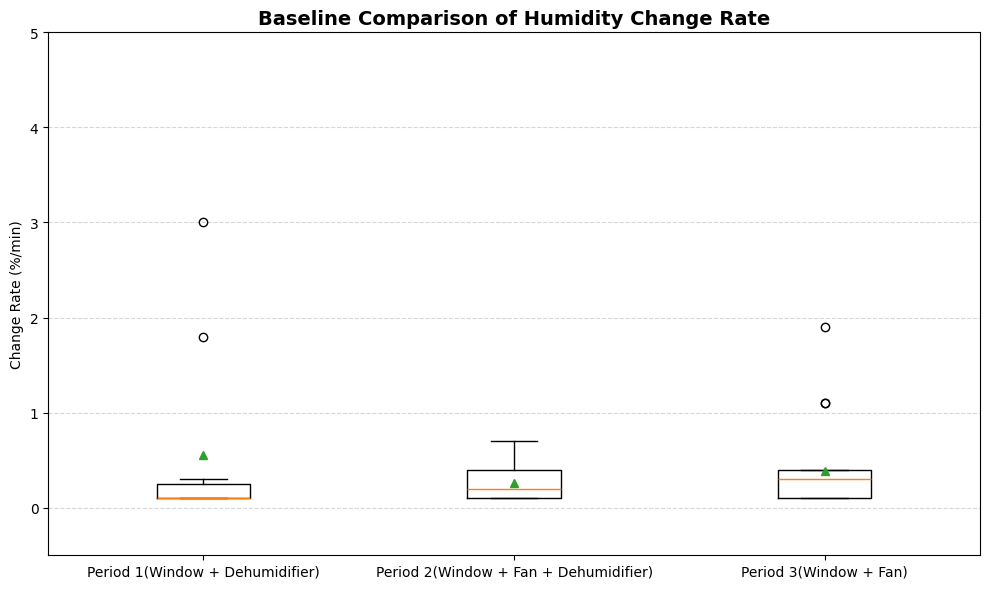

In [233]:

def create_box_whisker_data(data) -> BoxWhiskerResult:
    clean_time_mask = (data['ts'].dt.hour >= 3) & (data['ts'].dt.hour < 6)
    baseline_df = data[clean_time_mask].copy()
    baseline_df['diff_time_min'] = baseline_df['ts'].diff().dt.total_seconds()/60
    
    baseline_df = baseline_df.dropna(subset=['diff_time_min']).reset_index(drop = True)
    baseline_df = baseline_df[baseline_df['diff_time_min'] > 0].reset_index(drop=True)
    baseline_df['diff_humid'] = baseline_df['humidity'].diff()
    baseline_df = baseline_df.dropna(subset=['diff_humid']).reset_index(drop = True)
    
    baseline_df['diff_humid_min'] = (baseline_df['diff_humid'] / baseline_df['diff_time_min']).round(1)
    clean_data = baseline_df[baseline_df['diff_humid'] >= 0]
    data_points = baseline_df['diff_humid_min'].dropna()
    data_points = baseline_df['diff_humid_min'].dropna()
    q1 = np.percentile(data_points, 25)
    median = np.percentile(data_points, 50)
    q3 = np.percentile(data_points, 75)
    mean = np.mean(data_points)
    iqr = q3 - q1
    upper_whisker = q3 + (1.5 * iqr)
    desc_base = baseline_df['diff_humid']
    actual_upper_whisker = np.max(data_points[data_points <= upper_whisker])
    outliers_df = baseline_df[baseline_df['diff_humid_min'] > upper_whisker]
    outlier_val = baseline_df["diff_humid_min"].max()
    return BoxWhiskerResult(
        clean_data=clean_data, 
        q1=q1,
        median=median,
        q3=q3,
        mean=mean,
        upper_whisker=upper_whisker,
        actual_upper_whisker=actual_upper_whisker,
        outliers_df=outliers_df,
        outlier_val=outlier_val,
        summary=data_points.describe(),
        desc_base=desc_base
    )
res1 = create_box_whisker_data(_df1)
res2 = create_box_whisker_data(_df2)
res3 = create_box_whisker_data(_df3)
print("period1's outlier: ",res1.outlier_val)
print("period2's outlier: ",res2.outlier_val)
print("period3's outlier: ",res3.outlier_val)

fig, ax = plt.subplots(figsize=(10, 6))
plot_data = [
    res1.outliers_df["diff_humid_min"],
    res2.outliers_df["diff_humid_min"],
    res3.outliers_df["diff_humid_min"],
]

ax.boxplot(plot_data, showmeans=True)
ax.set_xticklabels(["Period 1(Window + Dehumidifier)", "Period 2(Window + Fan + Dehumidifier)", "Period 3(Window + Fan)"])
ax.set_ylabel("Change Rate (%/min)")
ax.set_title("Baseline Comparison of Humidity Change Rate", fontsize=14, fontweight="bold")
ax.set_ylim(-0.5, 5.0)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [234]:


def count_shower_events(data_frame, threshold):
    PEAK_THRESHOLD = 80
    shower_df = data_frame.copy()
    shower_df['diff_time'] = data_frame['ts'].diff().dt.total_seconds().round(2)    
    shower_df['diff_time_min'] = shower_df['diff_time']/60
    shower_df = shower_df.dropna(subset='diff_time_min').reset_index(drop=True)
    shower_df['diff_humidity_min'] = (shower_df['humidity'].diff()/shower_df['diff_time_min']).round(2)
    shower_df = shower_df[(shower_df['diff_humidity_min'] > 0) & (shower_df['diff_time_min'] != 0)]
    shower_df['is_rising'] = shower_df['diff_humidity_min'] >= threshold
    rising_rows = shower_df[shower_df['is_rising']].copy()
    rising_rows['time_gap'] = rising_rows['ts'].diff().dt.total_seconds() / 60
    rising_rows['group'] = (rising_rows['time_gap'] > 10) | (rising_rows['time_gap'].isna())
    rising_rows['event_id'] = rising_rows['group'].cumsum()
    events = rising_rows.groupby('event_id').agg(
        start_time=('ts', 'min'),
        end_time=('ts', 'max'),
        peak_humidity=('humidity', 'max'),
        n_points=('ts', 'count')
    ).reset_index()
    events['duration_min'] = (events['end_time'] - events['start_time']).dt.total_seconds() / 60
    
    events['is_likely_shower'] = events['peak_humidity'] >= PEAK_THRESHOLD
    return events
events1 = count_shower_events(_df1.copy(), 3.0)
events2 = count_shower_events(_df2.copy(), 0.7)
events3 = count_shower_events(_df3.copy(), 1.9)

print(f"total increasing event1: {len(events1)}")
print(f"total increasing event2: {len(events2)}")
print(f"total increasing event3: {len(events3)}")
print(f"peak >= {80}% event1 numbers: {events1['is_likely_shower'].sum()}")
print(f"peak >= {80}% event2 numbers: {events2['is_likely_shower'].sum()}")
print(f"peak >= {80}% event3 numbers: {events3['is_likely_shower'].sum()}")


total increasing event1: 117
total increasing event2: 187
total increasing event3: 75
peak >= 80% event1 numbers: 53
peak >= 80% event2 numbers: 50
peak >= 80% event3 numbers: 49


## Cumulative Amount of Time in the Risk Zone
In addition to analyzing individual shower events, I also calculated the total cumulative time the room spent in the risk zone during each period. 

The overall reduction in risk exposure is detailed below:

| Period | Date Range | Total Time in Risk Zone |
| :--- | :--- | :--- |
| **Period 1**  | 2026-04-27 – 2026-05-11 | 609.5 mins |
| **Period 2**  | 2026-05-12 – 2026-05-26 | 483.1 mins |
| **Period 3**  | 2026-06-09 – 2026-06-23 | 422.5 mins |

/var/folders/k_/_3_znhjx2dq3hsgtynlj7d380000gn/T/ipykernel_14220/89899364.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (~d['in_event'].shift(1).fillna(False)).astype(bool)
/var/folders/k_/_3_znhjx2dq3hsgtynlj7d380000gn/T/ipykernel_14220/89899364.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (~d['in_event'].shift(1).fillna(False)).astype(bool)
/var/folders/k_/_3_znhjx2dq3hsgtynlj7d380000gn/T/ipykernel_14220/89899364.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future versio

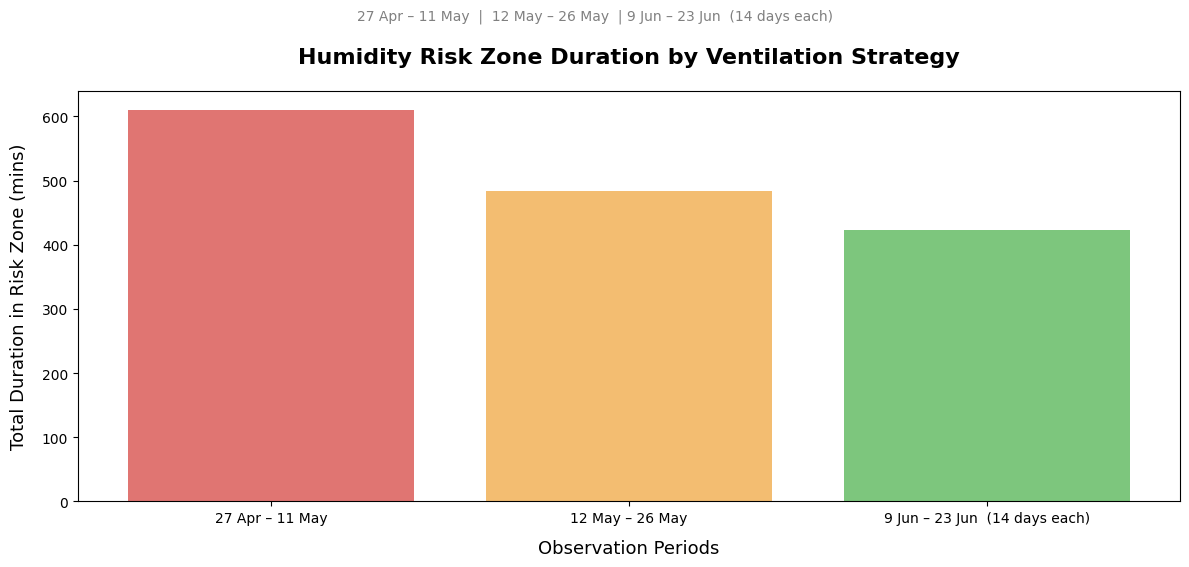

In [235]:
def compute_risk_zone_duration(data_frame, spread_threshold=3, max_gap_min=10, min_duration_min=1):
    d = data_frame.sort_values('ts').reset_index(drop=True).copy()
    d['in_event'] = d['spread'] <= spread_threshold
    d['time_gap'] = d['ts'].diff().dt.total_seconds() / 60

    d['event_start'] = (
        d['in_event']
        & (
            (~d['in_event'].shift(1).fillna(False)).astype(bool)
            | (d['time_gap'] > max_gap_min)
        )
    )
    d['event_id'] = d['event_start'].cumsum()

    filtered = d[d['in_event']].copy()
    ep = filtered.groupby('event_id')['ts'].agg(start_time='min', end_time='max')
    ep['duration'] = ((ep['end_time'] - ep['start_time']).dt.total_seconds() / 60.0).round(1)
    ep = ep[ep['duration'] > min_duration_min]
    total_duration = ep['duration'].sum().round(1)
    return ep, total_duration

ep, total_duration = compute_risk_zone_duration(_df1)
ep2, total_duration2 = compute_risk_zone_duration(_df2)
ep3, total_duration3 = compute_risk_zone_duration(_df3)
x = [
    "27 Apr – 11 May",
    "12 May – 26 May",
    "9 Jun – 23 Jun  (14 days each)",
]
y = [total_duration, total_duration2, total_duration3]
fig,ax = plt.subplots(figsize=(12, 6))
ax.bar(
    x,
    y,
    color=['#d9534f', '#f0ad4e', '#5cb85c'],
    alpha=0.8
)
ax.set_title('Humidity Risk Zone Duration by Ventilation Strategy', fontsize=16, fontweight='bold', pad=20)
fig.text(0.5, 0.92, '27 Apr – 11 May  |  12 May – 26 May  | 9 Jun – 23 Jun  (14 days each)', 
         ha='center', fontsize=10, color='gray')
plt.xlabel('Observation Periods', fontsize=13, labelpad=10)
plt.ylabel('Total Duration in Risk Zone (mins)', fontsize=13, labelpad=10)
plt.tight_layout(rect=[0, 0, 1, 0.90]) 
plt.show()


## Normalising for Fair Comparison

However, as shown above, the total number of shower events varied across each period. To ensure a fair comparison, I normalized the duration spent in the risk zone relative to the number of showers.

The normalized results (average time spent in the risk zone per shower) are as follows:

| Period | Range | Normalized Time in Risk Zone (per event) |
| :--- | :--- | :--- |
| **Period 1**  | 2026-04-27 – 2026-05-11 | 11.50 |
| **Period 2**  | 2026-05-12 – 2026-05-26 | 9.66 |
| **Period 3**  | 2026-06-09 – 2026-06-23 | 8.62 |

nomalised time1 of staying in the zone:  11.5
nomalised time2 of staying in the zone:  9.66
nomalised time3 of staying in the zone 8.62


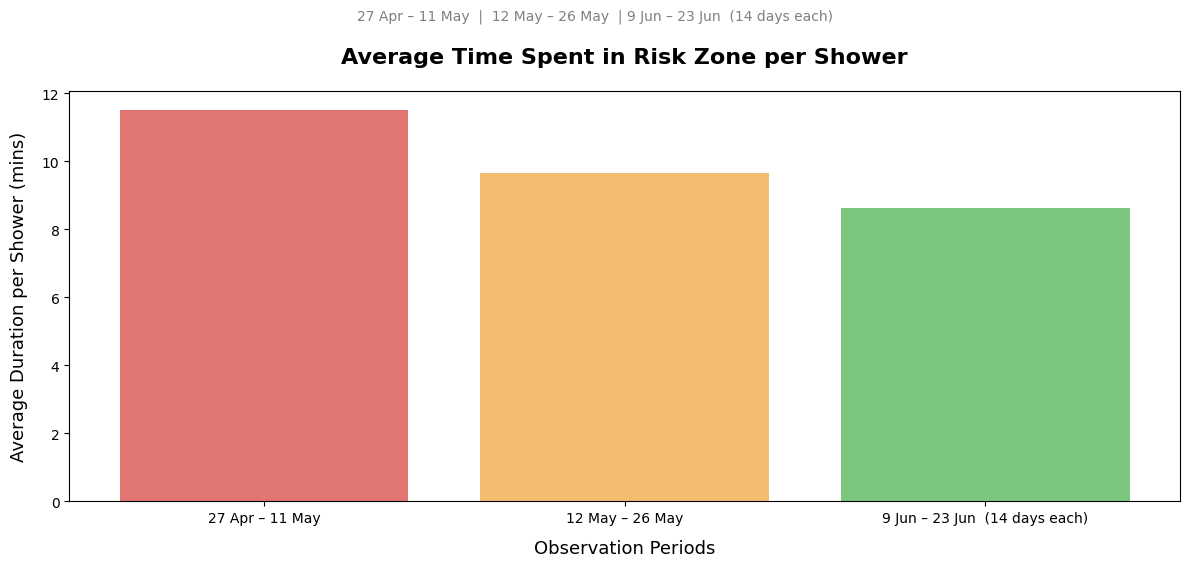

In [236]:
normalised_duration1 = (total_duration / events1['is_likely_shower'].sum()).round(2)
normalised_duration2 = (total_duration2 / events2['is_likely_shower'].sum()).round(2)
normalised_duration3 = (total_duration3 / events3['is_likely_shower'].sum()).round(2)
print("nomalised time1 of staying in the zone: ", normalised_duration1)
print("nomalised time2 of staying in the zone: ", normalised_duration2)
print("nomalised time3 of staying in the zone", normalised_duration3)
x = [
    "27 Apr – 11 May",
    "12 May – 26 May",
    "9 Jun – 23 Jun  (14 days each)",
]
y = [normalised_duration1, normalised_duration2, normalised_duration3]
fig,ax = plt.subplots(figsize=(12, 6))
ax.bar(
    x,
    y,
    color=['#d9534f', '#f0ad4e', '#5cb85c'],
    alpha=0.8
)

ax.set_title('Average Time Spent in Risk Zone per Shower', fontsize=16, fontweight='bold', pad=20)
fig.text(0.5, 0.92, '27 Apr – 11 May  |  12 May – 26 May  | 9 Jun – 23 Jun  (14 days each)', 
         ha='center', fontsize=10, color='gray')

plt.xlabel('Observation Periods', fontsize=13, labelpad=10)
plt.ylabel('Average Duration per Shower (mins)', fontsize=13, labelpad=10)

plt.tight_layout(rect=[0, 0, 1, 0.90]) 
plt.show()

### Visual Comparison: Mirror Condensation Before vs After Fan Installation

As a simple visual sanity check alongside the numeric results above, the photos below compare the bathroom mirror condensation with and without the fan running.

![Mirror condensation comparison without and with fan](./images/result.png)

## Conclusion
While both the data and my intuition suggest that adding a circulation fan is highly effective, a critical limitation remains. 

The overall results are heavily dependent on the specific thresholds I established. However, these thresholds were largely chosen based on my gut feeling (heuristically defined) and have yet to be rigorously validated. 

To close this gap, I am considering the following next steps:
1. **Machine Learning Labeling:** Building a structured ground-truth dataset to refine the baseline.
2. **Deep Learning Approach:** Implementing an anomaly detection model to identify shower events without relying on manual thresholds.